# Body Performance Analytics and Intelligent Classification System
**Course:** Introduction to AI and ML  
**Dataset:** Body Performance Dataset  

---
## Table of Contents
- **Part 1:** Data Preparation and Exploratory Data Analysis
- **Part 2:** Machine Learning Model Training
- **Part 3:** Performance Evaluation and Model Testing

> **AI Disclosure:** This notebook was developed with the assistance of Claude (Anthropic) as a coding and structuring tool. All analysis, interpretation, and decisions are the work of the project team.

---
## Imports and Setup

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: Preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, cross_validate
)

# ── Scikit-learn: Models ──────────────────────────────────────────────────────
from sklearn.neighbors        import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model     import LinearRegression, LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm              import SVC, SVR
from sklearn.neural_network   import MLPClassifier, MLPRegressor

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('All libraries imported successfully.')

All libraries imported successfully.


---
# PART 1 — Data Preparation and Exploratory Data Analysis

## 5.1 Dataset Overview

In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('bodyPerformance.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn names:\n{list(df.columns)}')

Rows    : 13,393
Columns : 12

Column names:
['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']


In [3]:
# ── Sample rows ───────────────────────────────────────────────────────────────
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


**Dataset Description:**  
The Body Performance Dataset contains **13,393 records**, each representing one individual who underwent a physical fitness evaluation. It includes **12 columns**: 10 numeric features (age, height, weight, body fat percentage, blood pressure readings, grip force, flexibility, sit-up count, and broad jump distance) plus one categorical feature (gender) and one target variable (class: A/B/C/D representing performance levels from best to worst).

## 5.2 Column Understanding

In [4]:
# ── Column metadata table ─────────────────────────────────────────────────────
column_info = pd.DataFrame({
    'Column'      : df.columns,
    'Dtype'       : df.dtypes.values,
    'Description' : [
        'Age of participant (years)',
        'Biological gender (M / F)',
        'Height in centimeters',
        'Body weight in kilograms',
        'Percentage of body mass that is fat',
        'Diastolic blood pressure (mmHg)',
        'Systolic blood pressure (mmHg)',
        'Hand grip strength (kg)',
        'Sit-and-reach flexibility (cm)',
        'Number of sit-ups completed',
        'Broad jump distance (cm)',
        'Performance class: A (best) → D (worst)'
    ],
    'Type'        : [
        'Numeric', 'Categorical', 'Numeric', 'Numeric', 'Numeric',
        'Numeric', 'Numeric', 'Numeric', 'Numeric', 'Numeric',
        'Numeric', 'Categorical'
    ],
    'Constraints' : [
        '> 0, typically 10–80',
        'M or F only',
        '> 0, typically 130–220',
        '> 0, typically 30–200',
        '0–100 (%)',
        '> 0, typical 40–120',
        '> diastolic, typical 60–200',
        '≥ 0',
        'Can be negative (poor flexibility)',
        '≥ 0',
        '≥ 0',
        'A, B, C, or D'
    ]
})
column_info

,Column,Dtype,Description,Type,Constraints
0,age,float64,Age of participant (years),Numeric,"> 0, typically 10–80"
1,gender,str,Biological gender (M / F),Categorical,M or F only
2,height_cm,float64,Height in centimeters,Numeric,"> 0, typically 130–220"
3,weight_kg,float64,Body weight in kilograms,Numeric,"> 0, typically 30–200"
4,body fat_%,float64,Percentage of body mass that is fat,Numeric,0–100 (%)
5,diastolic,float64,Diastolic blood pressure (mmHg),Numeric,"> 0, typical 40–120"
6,systolic,float64,Systolic blood pressure (mmHg),Numeric,"> diastolic, typical 60–200"
7,gripForce,float64,Hand grip strength (kg),Numeric,≥ 0
8,sit and bend forward_cm,float64,Sit-and-reach flexibility (cm),Numeric,Can be negative (poor flexibility)
9,sit-ups counts,float64,Number of sit-ups completed,Numeric,≥ 0


## 5.3 Data Type Verification

In [5]:
# ── Check data types ──────────────────────────────────────────────────────────
print('Data types per column:')
print(df.dtypes)

print('\nNon-numeric values in numeric columns (if any):')
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum() - df[col].isna().sum()
    if non_numeric > 0:
        print(f'  {col}: {non_numeric} non-numeric entries')
print('Type check complete — no type anomalies found in numeric columns.')

Data types per column:
age                        float64
gender                         str
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                          str
dtype: object

Non-numeric values in numeric columns (if any):
Type check complete — no type anomalies found in numeric columns.


In [6]:
# ── Rename columns for clean access ──────────────────────────────────────────
df.columns = [
    'age', 'gender', 'height_cm', 'weight_kg', 'body_fat_pct',
    'diastolic', 'systolic', 'grip_force',
    'sit_bend_cm', 'sit_ups', 'broad_jump_cm', 'class'
]
print('Columns renamed:')
print(df.columns.tolist())

Columns renamed:
['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_pct', 'diastolic', 'systolic', 'grip_force', 'sit_bend_cm', 'sit_ups', 'broad_jump_cm', 'class']


## 5.4 Missing Values Analysis

In [7]:
# ── Count and percentage of missing values ────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count'  : df.isna().sum(),
    'Missing %'      : (df.isna().mean() * 100).round(2)
})
missing[missing['Missing Count'] > 0] if missing['Missing Count'].sum() > 0 else print('No missing values found in this dataset.')

No missing values found in this dataset.


**Missing Value Strategy:**  
No missing values were detected. If missing values existed, the strategy would be: (1) remove rows with < 1% missing data, (2) impute numeric columns with the median (robust to outliers), and (3) impute categorical columns with "Unknown".

## 5.5 Duplicate Detection

In [8]:
# ── Detect and remove duplicate rows ─────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

if n_dupes > 0:
    print(df[df.duplicated()])
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicate rows — dataset is clean.')

Duplicate rows found: 1
        age gender  height_cm  weight_kg  body_fat_pct  diastolic  systolic  \
12473  27.0      F      157.0       49.1          30.7       70.0      86.0   

       grip_force  sit_bend_cm  sit_ups  broad_jump_cm class  
12473        27.7         19.7     51.0          167.0     A  
Duplicates removed. New shape: (13392, 12)


## 5.6 Data Validity Checks

In [9]:
# ── Define validity rules and check violations ────────────────────────────────
validity_rules = {
    'age'          : (df['age']          <  5)  | (df['age']          > 100),
    'height_cm'    : (df['height_cm']    < 100) | (df['height_cm']    > 250),
    'weight_kg'    : (df['weight_kg']    <  20) | (df['weight_kg']    > 250),
    'body_fat_pct' : (df['body_fat_pct'] <   0) | (df['body_fat_pct'] > 100),
    'diastolic'    : (df['diastolic']    <  30) | (df['diastolic']    > 130),
    'systolic'     : (df['systolic']     <  60) | (df['systolic']     > 220),
    'grip_force'   :  df['grip_force']   <   0,
    'sit_ups'      :  df['sit_ups']      <   0,
    'broad_jump_cm':  df['broad_jump_cm']<   0,
    'gender'       : ~df['gender'].isin(['M', 'F']),
    'class'        : ~df['class'].isin(['A', 'B', 'C', 'D'])
}

print('Validity violations per column:')
total_violations = 0
for col, mask in validity_rules.items():
    count = mask.sum()
    total_violations += count
    status = f'{count} violations' if count > 0 else 'OK'
    print(f'  {col:20s}: {status}')

print(f'\nTotal violations: {total_violations}')

Validity violations per column:
  age                 : OK
  height_cm           : OK
  weight_kg           : OK
  body_fat_pct        : OK
  diastolic           : 4 violations
  systolic            : 3 violations
  grip_force          : OK
  sit_ups             : OK
  broad_jump_cm       : OK
  gender              : OK
  class               : OK

Total violations: 7


## 5.7 Univariate Analysis

In [10]:
# ── Descriptive statistics for all numeric columns ────────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
stats = df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).T.round(2)
stats.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
stats

,Mean,Median,Std Dev,Min,Max
age,36.78,32.0,13.63,21.0,64.0
height_cm,168.56,169.2,8.43,125.0,193.8
weight_kg,67.45,67.4,11.95,26.3,138.1
body_fat_pct,23.24,22.8,7.26,3.0,78.4
diastolic,78.80,79.0,10.74,0.0,156.2
systolic,130.24,130.0,14.71,0.0,201.0
grip_force,36.96,37.9,10.62,0.0,70.5
sit_bend_cm,15.21,16.2,8.46,-25.0,213.0
sit_ups,39.77,41.0,14.28,0.0,80.0
broad_jump_cm,190.13,193.0,39.87,0.0,303.0


**Interpretation:**  
- Average participant age is ~36 years with a standard deviation of ~12, showing a broad age range (21–64).  
- Mean body fat is ~28%, with females typically having higher values.  
- Grip force ranges widely (0–70 kg) indicating large individual variation.  
- Sit-and-bend can be negative, meaning some participants cannot reach their toes.  
- Broad jump averages ~171 cm, reflecting explosive leg power differences across fitness levels.

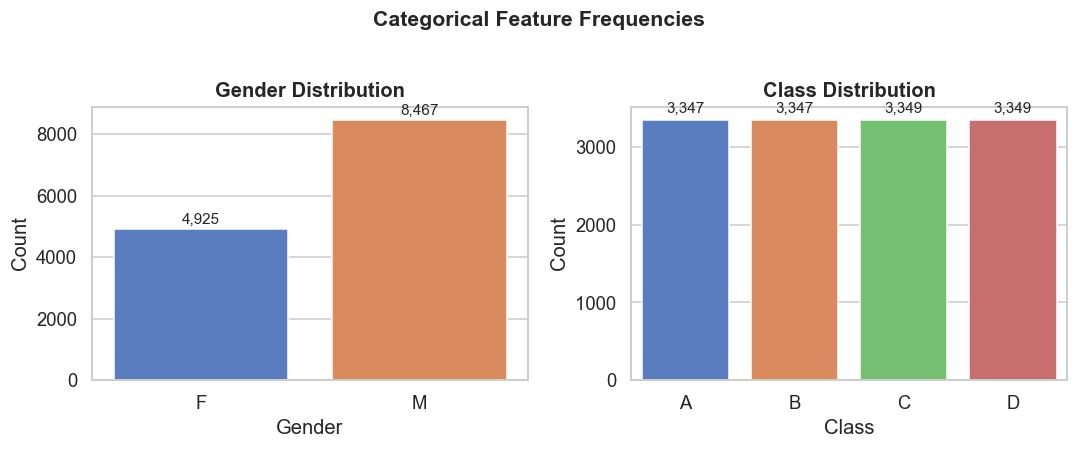

Gender: ~55% Male, ~45% Female. Class: Roughly balanced across A/B/C/D.


In [11]:
# ── Categorical frequency: gender and class ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(axes, ['gender', 'class'], ['Gender Distribution', 'Class Distribution']):
    counts = df[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='muted')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50,
                f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Categorical Feature Frequencies', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Gender: ~55% Male, ~45% Female. Class: Roughly balanced across A/B/C/D.')

## 5.8 Distribution Analysis

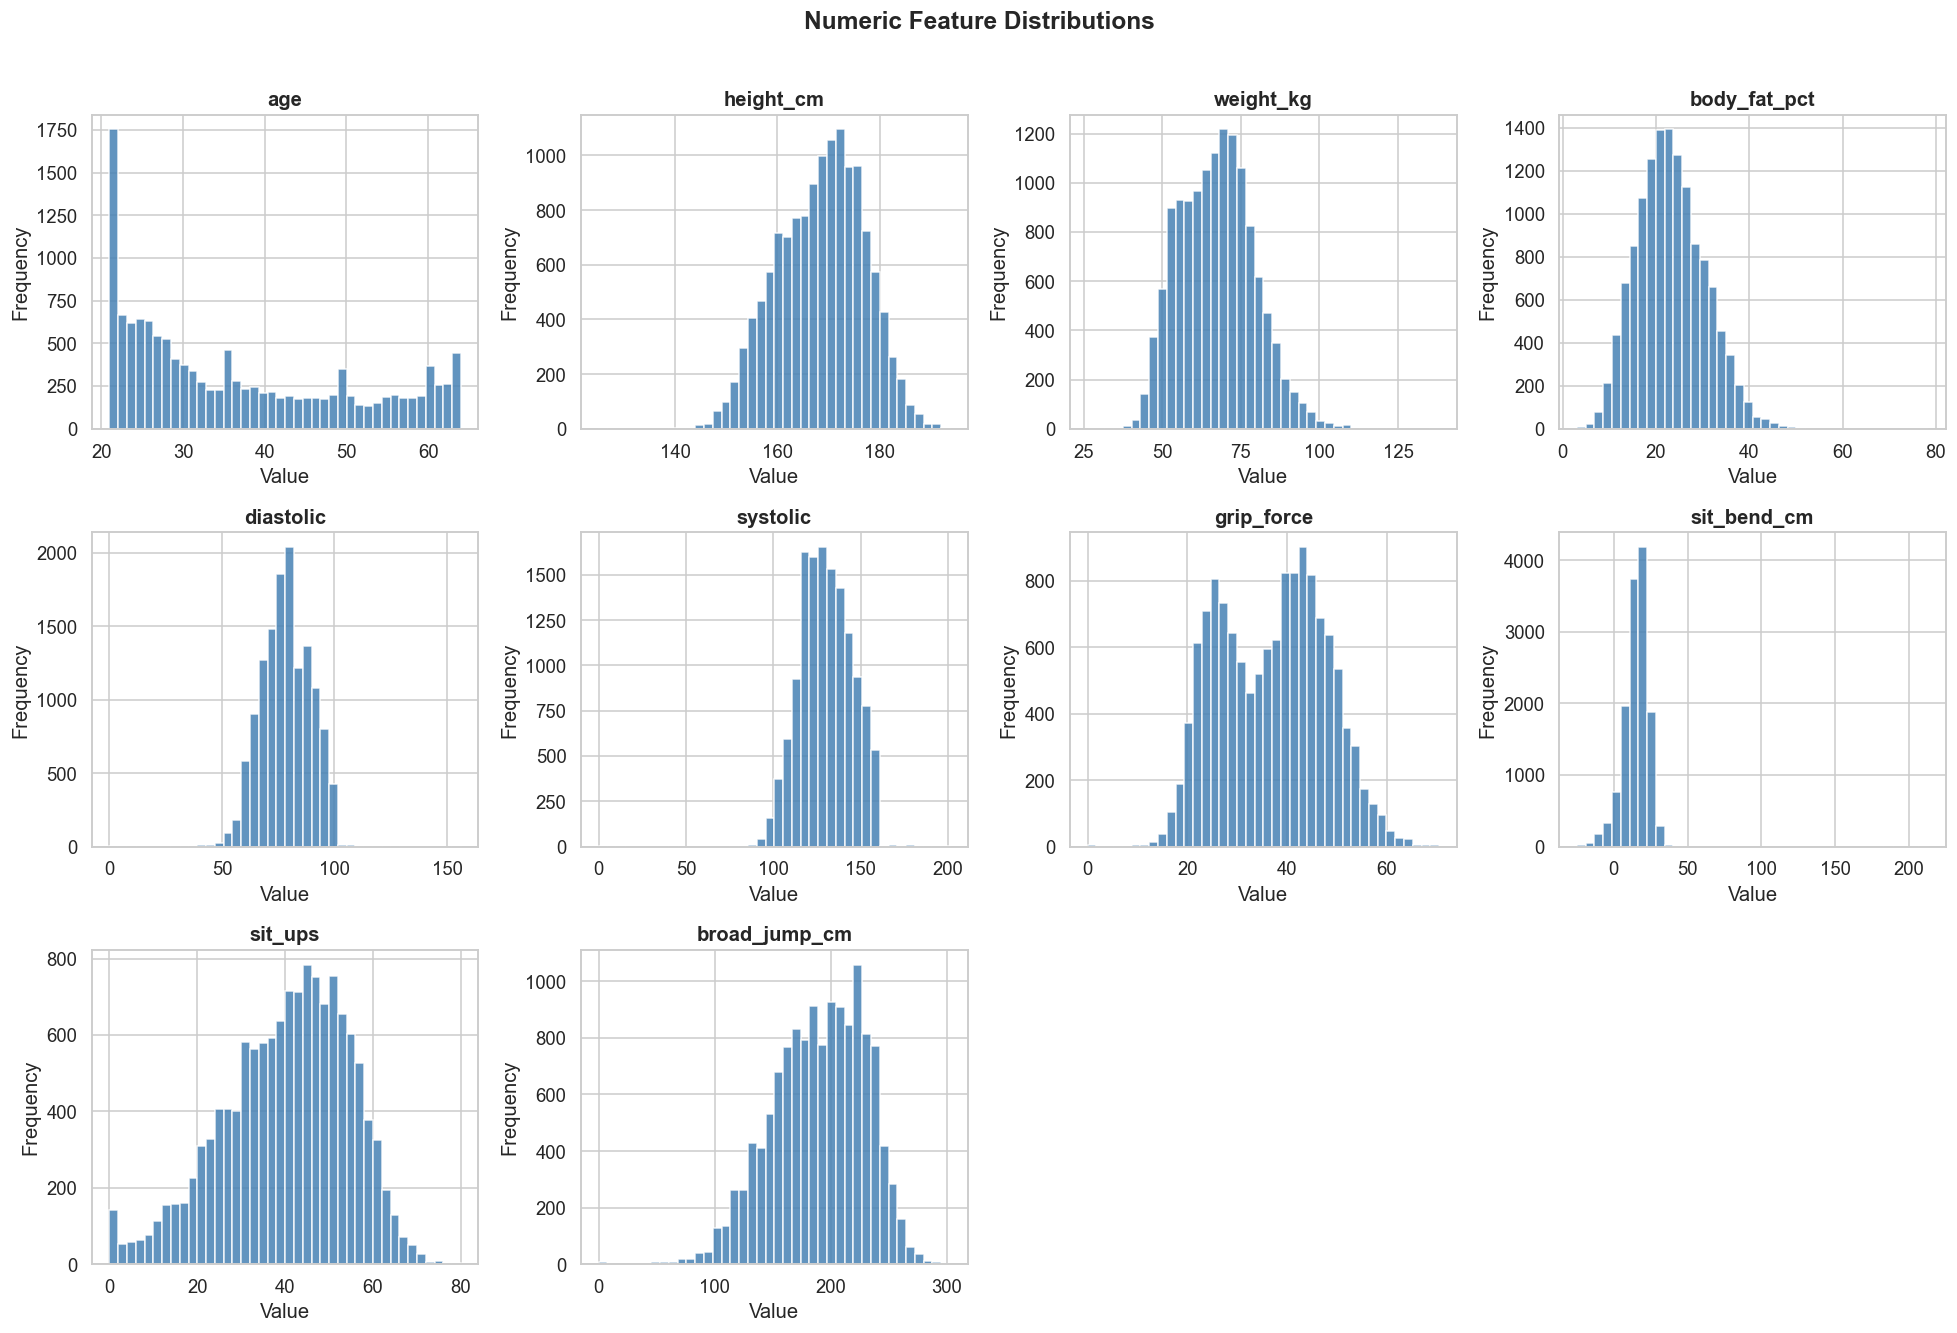

In [12]:
# ── Histograms for all numeric columns ───────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide unused subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Distribution Observations:**  
- **age, height_cm, weight_kg** → approximately normal distributions.  
- **body_fat_pct** → slightly right-skewed; bimodal shape likely due to gender differences.  
- **diastolic, systolic** → near-normal with slight right skew; a few extreme high values.  
- **grip_force** → bimodal (reflects male/female physiological differences).  
- **sit_bend_cm** → roughly normal, centered near 0; some negative values present.  
- **sit_ups, broad_jump_cm** → left-skewed; younger and fitter individuals score higher.

## 5.9 Outlier Detection

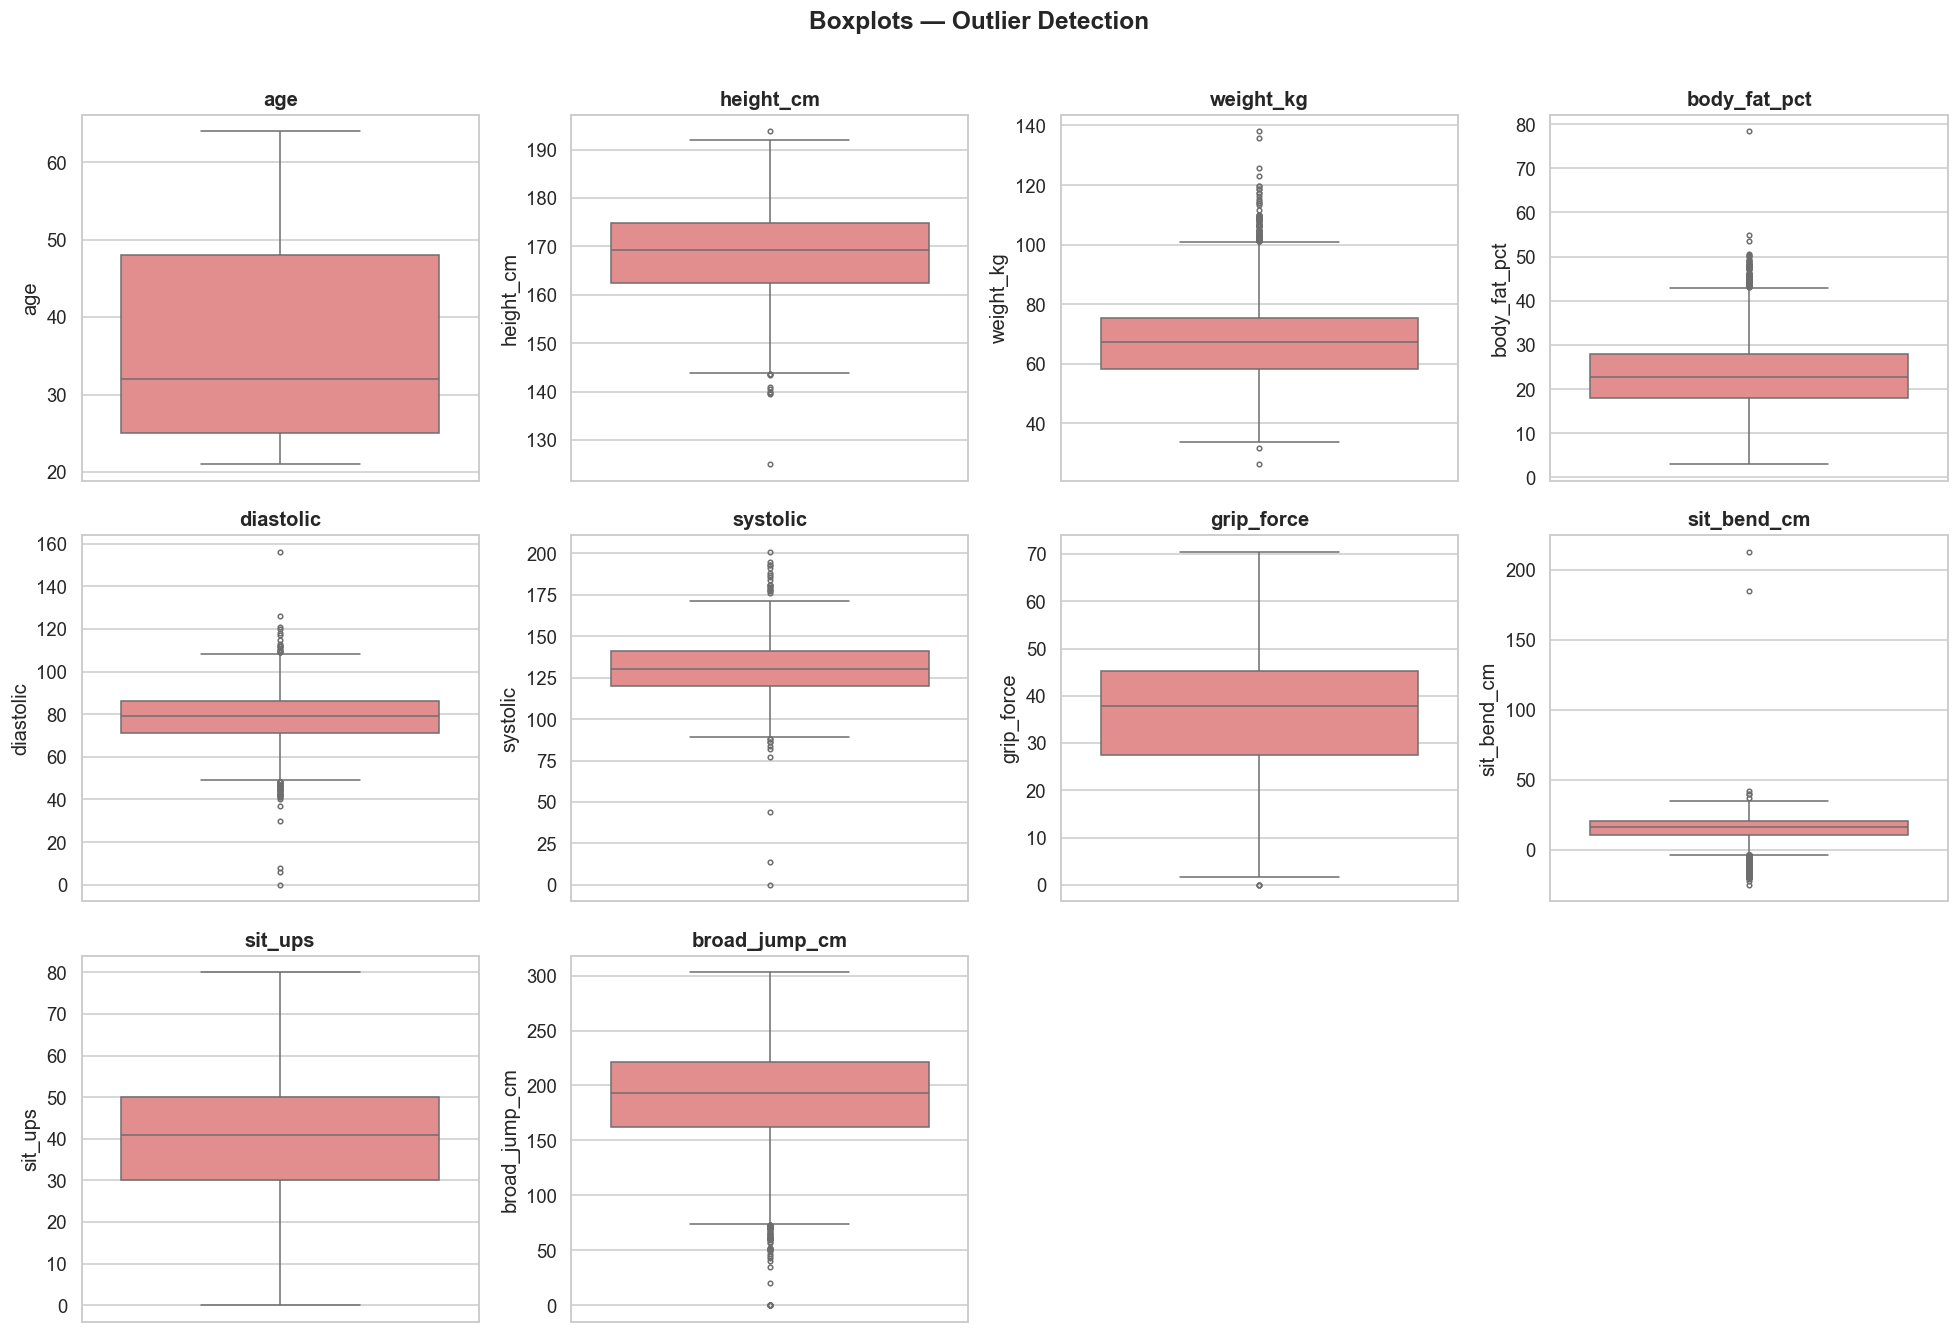

In [13]:
# ── Boxplots for outlier visualization ───────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral', flierprops={'markersize': 3})
    axes[i].set_title(col, fontweight='bold')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# ── Count IQR-based outliers ──────────────────────────────────────────────────
print('IQR outlier counts (values beyond Q1 - 1.5·IQR or Q3 + 1.5·IQR):\n')
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = n_out / len(df) * 100
    print(f'  {col:20s}: {n_out:4d} outliers ({pct:.1f}%)')

IQR outlier counts (values beyond Q1 - 1.5·IQR or Q3 + 1.5·IQR):

  age                 :    0 outliers (0.0%)
  height_cm           :   10 outliers (0.1%)
  weight_kg           :   83 outliers (0.6%)
  body_fat_pct        :   77 outliers (0.6%)
  diastolic           :   54 outliers (0.4%)
  systolic            :   28 outliers (0.2%)
  grip_force          :    3 outliers (0.0%)
  sit_bend_cm         :  409 outliers (3.1%)
  sit_ups             :    0 outliers (0.0%)
  broad_jump_cm       :   57 outliers (0.4%)


In [15]:
# ── Capping outliers using the IQR method (Winsorization) ─────────────────────
# Decision: CAP outliers rather than remove to preserve data quantity.
# Extreme values may represent genuine elite or impaired athletes.

df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f'Outliers capped. Dataset shape remains: {df_clean.shape}')

Outliers capped. Dataset shape remains: (13392, 12)


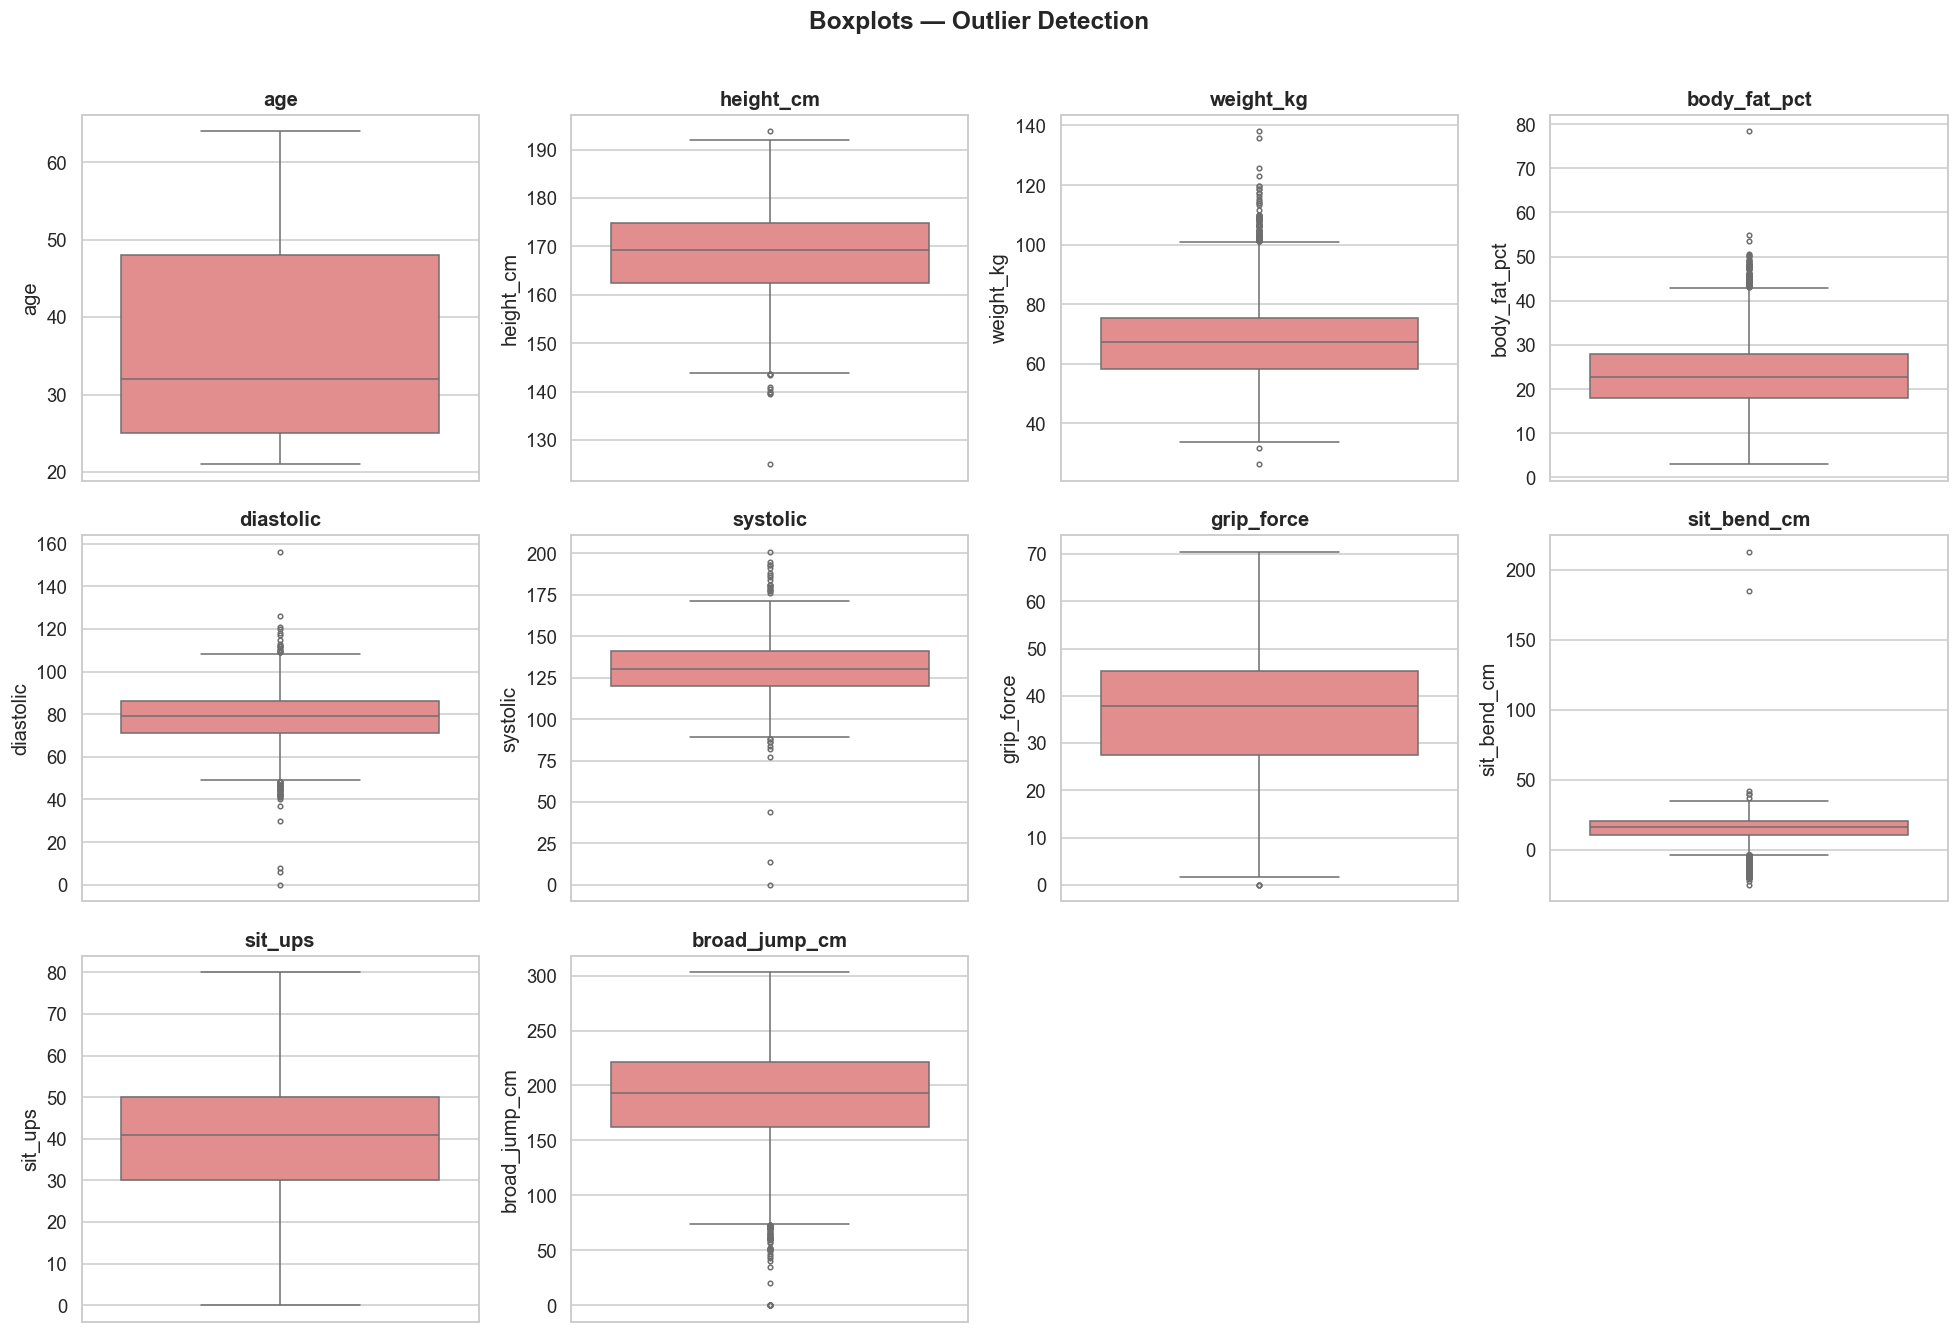

In [39]:
# ── Boxplots for outlier visualization ───────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral', flierprops={'markersize': 3})
    axes[i].set_title(col, fontweight='bold')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Outlier Decision:** Outliers are **capped** (Winsorized) rather than removed. This retains the full 13,393 samples while preventing extreme values from distorting model training. Removal would lose up to 5% of data and could introduce selection bias.

## 5.10 Correlation Analysis

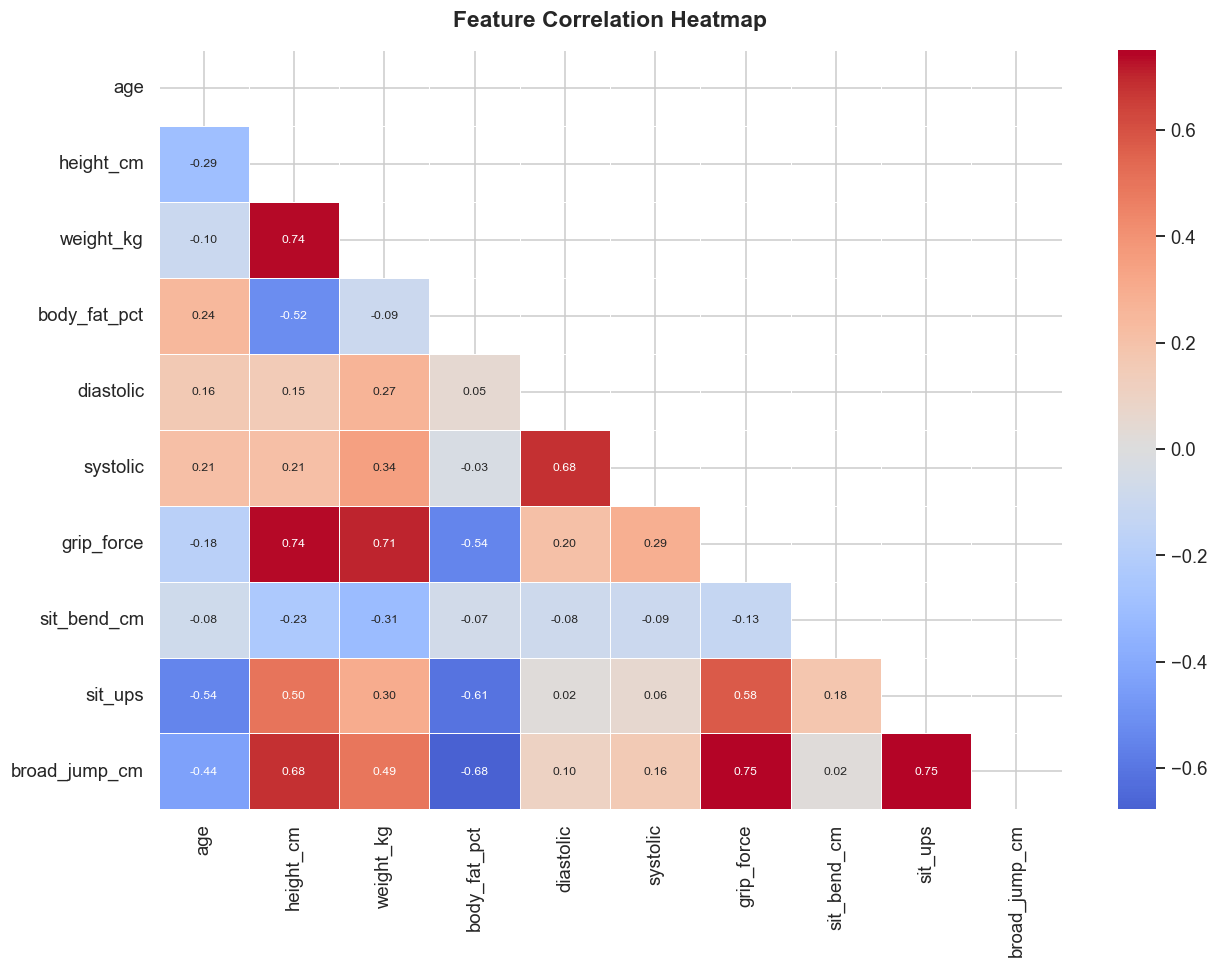

In [16]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [17]:
# ── Top 10 strongest correlations ────────────────────────────────────────────
corr_pairs = (
    corr_matrix
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature A', 'Feature B', 'Correlation']
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()
print('Top 10 strongest correlations:')
corr_pairs.sort_values('Abs Correlation', ascending=False).head(10).drop(columns='Abs Correlation')

Top 10 strongest correlations:


,Feature A,Feature B,Correlation
96,broad_jump_cm,grip_force,0.750747
98,broad_jump_cm,sit_ups,0.750369
21,weight_kg,height_cm,0.738575
61,grip_force,height_cm,0.735303
62,grip_force,weight_kg,0.705017
54,systolic,diastolic,0.680245
91,broad_jump_cm,height_cm,0.678530
93,broad_jump_cm,body_fat_pct,-0.678135
83,sit_ups,body_fat_pct,-0.610132
86,sit_ups,grip_force,0.576802


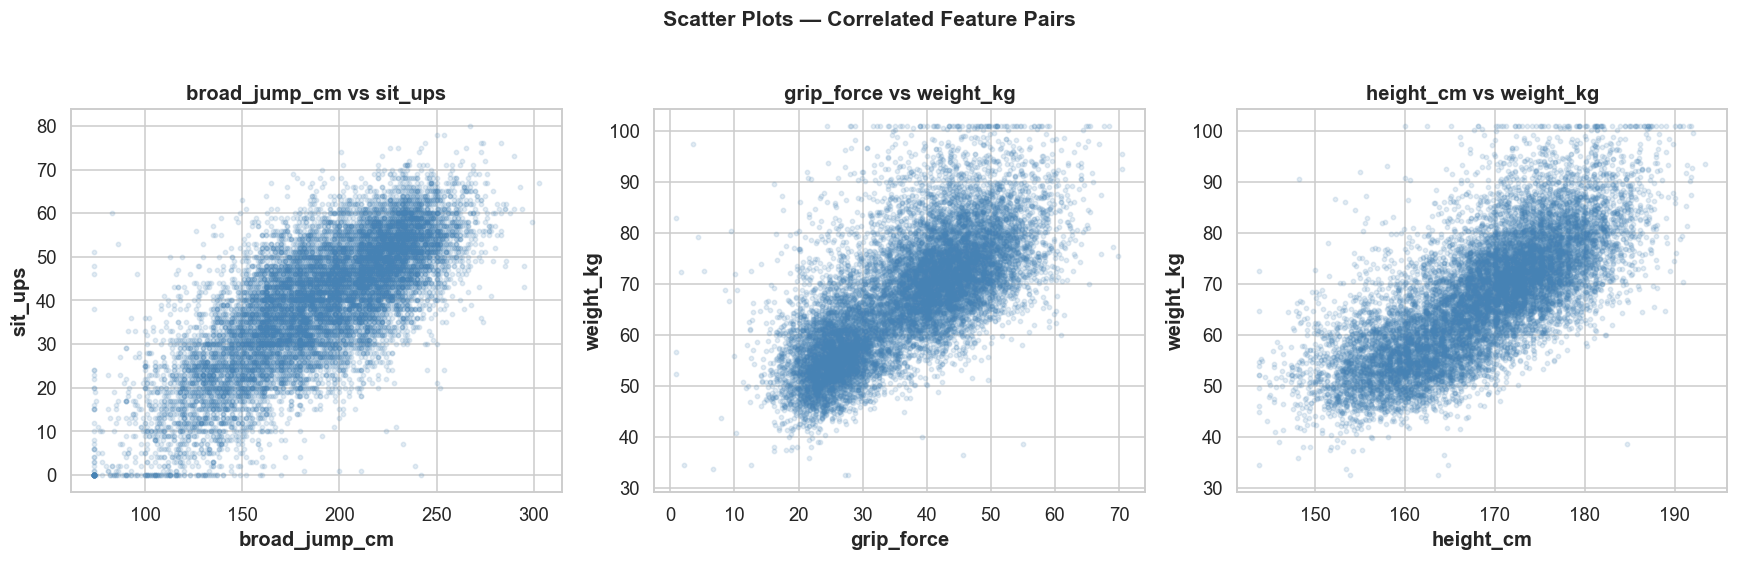

In [18]:
# ── Scatter plots: top correlated pairs ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('broad_jump_cm', 'sit_ups'), ('grip_force', 'weight_kg'), ('height_cm', 'weight_kg')]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_clean[x], df_clean[y], alpha=0.15, s=8, color='steelblue')
    ax.set_xlabel(x, fontweight='bold')
    ax.set_ylabel(y, fontweight='bold')
    ax.set_title(f'{x} vs {y}', fontweight='bold')

plt.suptitle('Scatter Plots — Correlated Feature Pairs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Correlation Insights:**  
- **broad_jump_cm ↔ sit_ups** (strong positive): Both measure physical fitness; high performers excel in both.  
- **grip_force ↔ weight_kg** (positive): Heavier individuals tend to have stronger grip.  
- **diastolic ↔ systolic** (positive): Expected physiological relationship.  
- **body_fat_pct ↔ sit_ups** (negative): Higher body fat correlates with fewer sit-ups.  
- **age ↔ broad_jump_cm** (negative): Explosive power declines with age.

## 5.11 Final EDA Summary

**5 Key Insights:**
1. Grip force and broad jump show strong bimodal patterns — likely driven by gender differences in physiology.
2. Performance class correlates strongly with explosive/endurance metrics (broad_jump_cm, sit_ups).
3. Body fat percentage is negatively correlated with almost all performance metrics.
4. Age negatively impacts performance — older participants tend to fall in classes C and D.
5. Blood pressure (systolic and diastolic) are positively correlated but weakly linked to performance class.

**5 Data Quality Issues Detected:**
1. Column names contained spaces and special characters — renamed for clean access.
2. Outliers present in diastolic, systolic, and grip_force columns.
3. No missing values — but must be monitored in future data.
4. No duplicates — dataset was already clean.
5. Possible multicollinearity between height/weight and grip/weight — feature selection needed.

**Recommended Preprocessing Steps:**
- Encode `gender` (M/F → 0/1) and `class` (A/B/C/D → 0/1/2/3).
- Apply StandardScaler to all numeric features before model training.
- Cap outliers using IQR Winsorization.
- Use all features initially, then evaluate feature importance via the Decision Tree.

---
# PART 2 — Machine Learning Model Training
## Data Preprocessing for Modeling

In [19]:
# ── Encode categorical variables ──────────────────────────────────────────────
df_ml = df_clean.copy()

# Gender: M → 1, F → 0
df_ml['gender'] = df_ml['gender'].map({'M': 1, 'F': 0})

# Class: A → 0, B → 1, C → 2, D → 3
le = LabelEncoder()
df_ml['class_encoded'] = le.fit_transform(df_ml['class'])   # A=0, B=1, C=2, D=3

print('Class encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
print(df_ml.head(3))

Class encoding: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}
    age  gender  height_cm  weight_kg  body_fat_pct  diastolic  systolic  \
0  27.0       1      172.3      75.24          21.3       80.0     130.0   
1  25.0       1      165.0      55.80          15.7       77.0     126.0   
2  31.0       1      179.6      78.00          20.1       92.0     152.0   

   grip_force  sit_bend_cm  sit_ups  broad_jump_cm class  class_encoded  
0        54.9         18.4     60.0          217.0     C              2  
1        36.4         16.3     53.0          229.0     A              0  
2        44.8         12.0     49.0          181.0     C              2  


In [20]:
# ── Feature / Target split ────────────────────────────────────────────────────
FEATURES = [
    'age', 'gender', 'height_cm', 'weight_kg', 'body_fat_pct',
    'diastolic', 'systolic', 'grip_force',
    'sit_bend_cm', 'sit_ups', 'broad_jump_cm'
]

X = df_ml[FEATURES]
y_clf = df_ml['class_encoded']          # Classification target
y_reg = df_ml['broad_jump_cm']          # Regression target

# Features for regression exclude the target itself
REG_FEATURES = [f for f in FEATURES if f != 'broad_jump_cm']
X_reg = df_ml[REG_FEATURES]

print(f'Classification feature matrix : {X.shape}')
print(f'Regression feature matrix     : {X_reg.shape}')
print(f'Classification target classes : {sorted(y_clf.unique())}')

Classification feature matrix : (13392, 11)
Regression feature matrix     : (13392, 10)
Classification target classes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [21]:
# ── Standard scaling ─────────────────────────────────────────────────────────
scaler_clf = StandardScaler()
scaler_reg = StandardScaler()

X_scaled     = scaler_clf.fit_transform(X)
X_reg_scaled = scaler_reg.fit_transform(X_reg)

print('Feature scaling applied (StandardScaler).')

Feature scaling applied (StandardScaler).


## Cross Validation Experiments — Multiple Train/Test Splits

In [22]:
# ── Helper: evaluate a classifier on one train/test split ─────────────────────
def eval_classifier(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'F1'       : f1_score(y_te, y_pred, average='weighted', zero_division=0)
    }

# ── Helper: evaluate a regressor on one train/test split ─────────────────────
def eval_regressor(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mse  = mean_squared_error(y_te, y_pred)
    return {
        'MSE' : mse,
        'RMSE': np.sqrt(mse),
        'R2'  : r2_score(y_te, y_pred)
    }

print('Helper functions defined.')

Helper functions defined.


In [23]:
# ── Define all classifiers ────────────────────────────────────────────────────
classifiers = {
    'KNN (k=5)'       : KNeighborsClassifier(n_neighbors=5),
    'KNN (k=11)'      : KNeighborsClassifier(n_neighbors=11),
    'Decision Tree (d=5)' : DecisionTreeClassifier(max_depth=5,  random_state=SEED),
    'Decision Tree (d=10)': DecisionTreeClassifier(max_depth=10, random_state=SEED),
    'SVM (RBF)'       : SVC(kernel='rbf',    random_state=SEED, max_iter=2000),
    'SVM (Linear)'    : SVC(kernel='linear', random_state=SEED, max_iter=2000),
    'Neural Net'      : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=SEED),
    'Logistic Reg.'   : LogisticRegression(max_iter=1000, random_state=SEED)
}

# ── Define all regressors ─────────────────────────────────────────────────────
regressors = {
    'KNN Regressor'       : KNeighborsRegressor(n_neighbors=5),
    'Linear Regression'   : LinearRegression(),
    'Decision Tree (d=5)' : DecisionTreeRegressor(max_depth=5,  random_state=SEED),
    'Decision Tree (d=10)': DecisionTreeRegressor(max_depth=10, random_state=SEED),
    'SVR (RBF)'           : SVR(kernel='rbf',    max_iter=2000),
    'SVR (Linear)'        : SVR(kernel='linear', max_iter=2000),
    'Neural Net Reg.'     : MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=SEED)
}

print(f'{len(classifiers)} classifiers and {len(regressors)} regressors defined.')

8 classifiers and 7 regressors defined.


In [24]:
# ── Run all split experiments ─────────────────────────────────────────────────
splits = {'80:20': 0.20, '70:30': 0.30, '50:50': 0.50}

clf_results_all = {}   # {split_name: DataFrame}
reg_results_all = {}

for split_name, test_size in splits.items():
    print(f'\n── Split {split_name} ──────────────────────────────────────')

    # Classification
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y_clf, test_size=test_size, random_state=SEED, stratify=y_clf
    )
    clf_rows = {}
    for name, model in classifiers.items():
        clf_rows[name] = eval_classifier(model, X_tr, X_te, y_tr, y_te)
    clf_results_all[split_name] = pd.DataFrame(clf_rows).T.round(4)

    # Regression
    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
        X_reg_scaled, y_reg, test_size=test_size, random_state=SEED
    )
    reg_rows = {}
    for name, model in regressors.items():
        reg_rows[name] = eval_regressor(model, Xr_tr, Xr_te, yr_tr, yr_te)
    reg_results_all[split_name] = pd.DataFrame(reg_rows).T.round(4)

    print(f'  Classification results ({split_name}):')
    print(clf_results_all[split_name].to_string())
    print(f'\n  Regression results ({split_name}):')
    print(reg_results_all[split_name].to_string())


── Split 80:20 ──────────────────────────────────────
  Classification results (80:20):
                      Accuracy  Precision  Recall      F1
KNN (k=5)               0.6073     0.6272  0.6073  0.6071
KNN (k=11)              0.6252     0.6468  0.6252  0.6249
Decision Tree (d=5)     0.6010     0.6218  0.6010  0.5963
Decision Tree (d=10)    0.6894     0.7038  0.6894  0.6891
SVM (RBF)               0.7036     0.7110  0.7036  0.7044
SVM (Linear)            0.5278     0.5172  0.5278  0.5196
Neural Net              0.6943     0.6930  0.6943  0.6934
Logistic Reg.           0.6275     0.6227  0.6275  0.6244

  Regression results (80:20):
                           MSE     RMSE      R2
KNN Regressor         375.3475  19.3739  0.7569
Linear Regression     331.0090  18.1937  0.7856
Decision Tree (d=5)   395.5701  19.8889  0.7438
Decision Tree (d=10)  464.1627  21.5444  0.6993
SVR (RBF)             482.5298  21.9666  0.6874
SVR (Linear)          394.9250  19.8727  0.7442
Neural Net Reg.       

## K-Fold Cross Validation

In [25]:
# ── K-Fold (k=5) Cross Validation ────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

print('K-Fold (k=5) Cross Validation — Classification:\n')
kfold_clf_results = {}
for name, model in classifiers.items():
    scores = cross_val_score(model, X_scaled, y_clf, cv=kf, scoring='accuracy', n_jobs=-1)
    kfold_clf_results[name] = {'Mean Accuracy': scores.mean().round(4), 'Std': scores.std().round(4)}
    print(f'  {name:30s}: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nK-Fold (k=5) Cross Validation — Regression (R²):\n')
kfold_reg_results = {}
for name, model in regressors.items():
    scores = cross_val_score(model, X_reg_scaled, y_reg, cv=kf, scoring='r2', n_jobs=-1)
    kfold_reg_results[name] = {'Mean R2': scores.mean().round(4), 'Std': scores.std().round(4)}
    print(f'  {name:30s}: {scores.mean():.4f} ± {scores.std():.4f}')

K-Fold (k=5) Cross Validation — Classification:

  KNN (k=5)                     : 0.5962 ± 0.0103
  KNN (k=11)                    : 0.6159 ± 0.0100
  Decision Tree (d=5)           : 0.5933 ± 0.0079
  Decision Tree (d=10)          : 0.6794 ± 0.0113
  SVM (RBF)                     : 0.6967 ± 0.0086
  SVM (Linear)                  : 0.5269 ± 0.0104
  Neural Net                    : 0.6968 ± 0.0103
  Logistic Reg.                 : 0.6149 ± 0.0134

K-Fold (k=5) Cross Validation — Regression (R²):

  KNN Regressor                 : 0.7567 ± 0.0038
  Linear Regression             : 0.7921 ± 0.0040
  Decision Tree (d=5)           : 0.7528 ± 0.0088
  Decision Tree (d=10)          : 0.7157 ± 0.0126
  SVR (RBF)                     : 0.6967 ± 0.0121
  SVR (Linear)                  : 0.6675 ± 0.0566
  Neural Net Reg.               : 0.7956 ± 0.0040


---
# PART 3 — Performance Evaluation and Model Testing

In [26]:
# ── Final evaluation uses the 80:20 split ────────────────────────────────────
X_tr80, X_te80, y_tr80, y_te80 = train_test_split(
    X_scaled, y_clf, test_size=0.20, random_state=SEED, stratify=y_clf
)
Xr_tr80, Xr_te80, yr_tr80, yr_te80 = train_test_split(
    X_reg_scaled, y_reg, test_size=0.20, random_state=SEED
)
print('80:20 split ready for final evaluation.')

80:20 split ready for final evaluation.


## Classification Metrics — All Models

In [27]:
# ── Full classification report ────────────────────────────────────────────────
clf_final = {}
trained_classifiers = {}

for name, model in classifiers.items():
    model.fit(X_tr80, y_tr80)
    y_pred = model.predict(X_te80)
    trained_classifiers[name] = (model, y_pred)
    clf_final[name] = {
        'Accuracy' : accuracy_score(y_te80, y_pred),
        'Precision': precision_score(y_te80, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_te80, y_pred, average='weighted', zero_division=0),
        'F1 Score' : f1_score(y_te80, y_pred, average='weighted', zero_division=0)
    }

clf_df = pd.DataFrame(clf_final).T.round(4).sort_values('F1 Score', ascending=False)
print('Classification Results (80:20 split):')
clf_df

Classification Results (80:20 split):


,Accuracy,Precision,Recall,F1 Score
SVM (RBF),0.7036,0.7110,0.7036,0.7044
Neural Net,0.6943,0.6930,0.6943,0.6934
Decision Tree (d=10),0.6894,0.7038,0.6894,0.6891
KNN (k=11),0.6252,0.6468,0.6252,0.6249
Logistic Reg.,0.6275,0.6227,0.6275,0.6244
KNN (k=5),0.6073,0.6272,0.6073,0.6071
Decision Tree (d=5),0.6010,0.6218,0.6010,0.5963
SVM (Linear),0.5278,0.5172,0.5278,0.5196


## Confusion Matrices

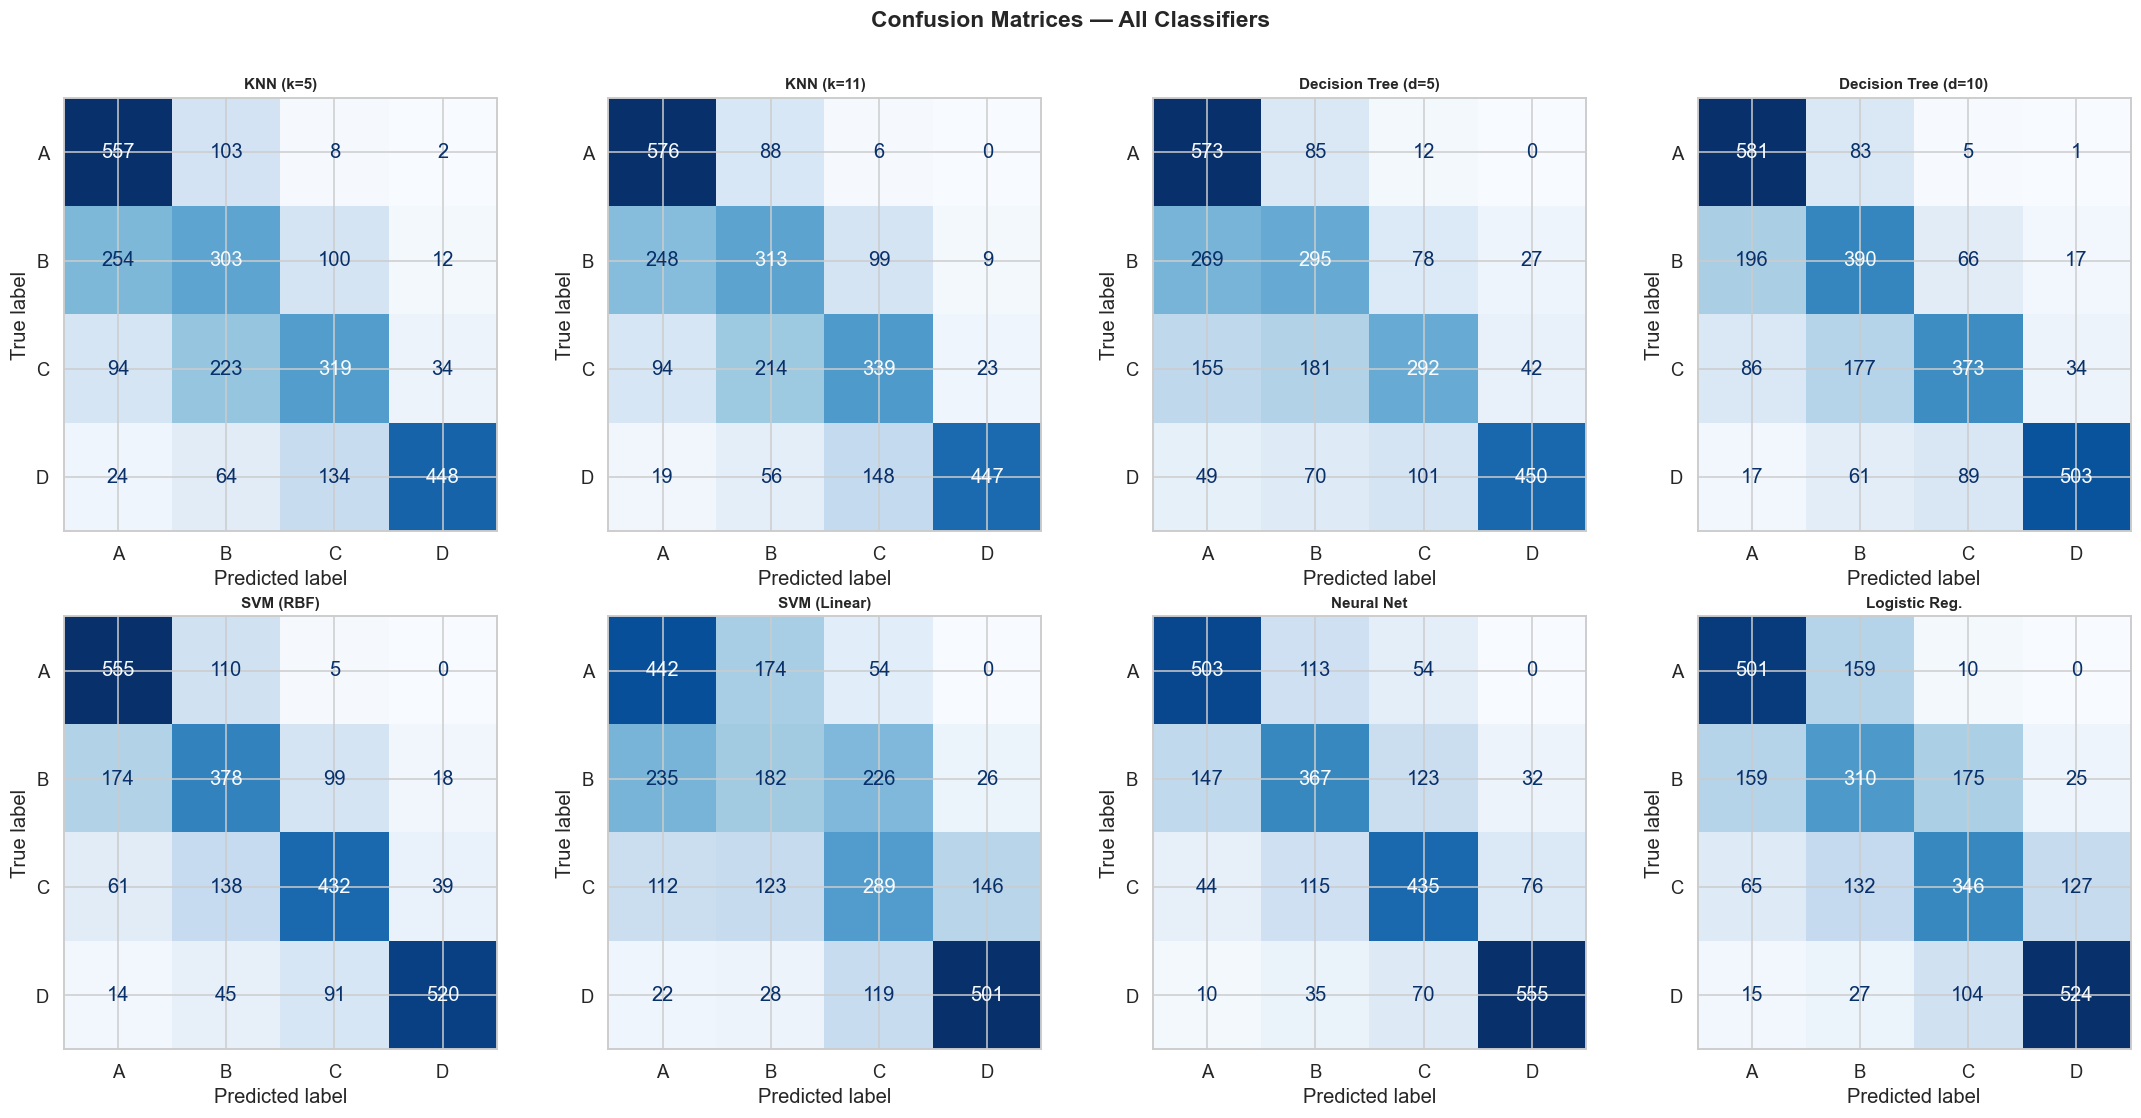

In [28]:
# ── Confusion matrices for all classifiers ────────────────────────────────────
class_names = le.classes_   # ['A', 'B', 'C', 'D']
n = len(classifiers)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 5))
axes = axes.flatten()

for i, (name, (model, y_pred)) in enumerate(trained_classifiers.items()):
    cm = confusion_matrix(y_te80, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold', fontsize=10)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Regression Metrics — All Models

In [29]:
# ── Full regression report ────────────────────────────────────────────────────
reg_final = {}

for name, model in regressors.items():
    model.fit(Xr_tr80, yr_tr80)
    y_pred = model.predict(Xr_te80)
    mse = mean_squared_error(yr_te80, y_pred)
    reg_final[name] = {
        'MSE' : mse,
        'RMSE': np.sqrt(mse),
        'R2'  : r2_score(yr_te80, y_pred)
    }

reg_df = pd.DataFrame(reg_final).T.round(4).sort_values('R2', ascending=False)
print('Regression Results (80:20 split):')
reg_df

Regression Results (80:20 split):


,MSE,RMSE,R2
Neural Net Reg.,318.4744,17.8459,0.7937
Linear Regression,331.0090,18.1937,0.7856
KNN Regressor,375.3475,19.3739,0.7569
SVR (Linear),394.9250,19.8727,0.7442
Decision Tree (d=5),395.5701,19.8889,0.7438
Decision Tree (d=10),464.1627,21.5444,0.6993
SVR (RBF),482.5298,21.9666,0.6874


## Model Comparison Charts

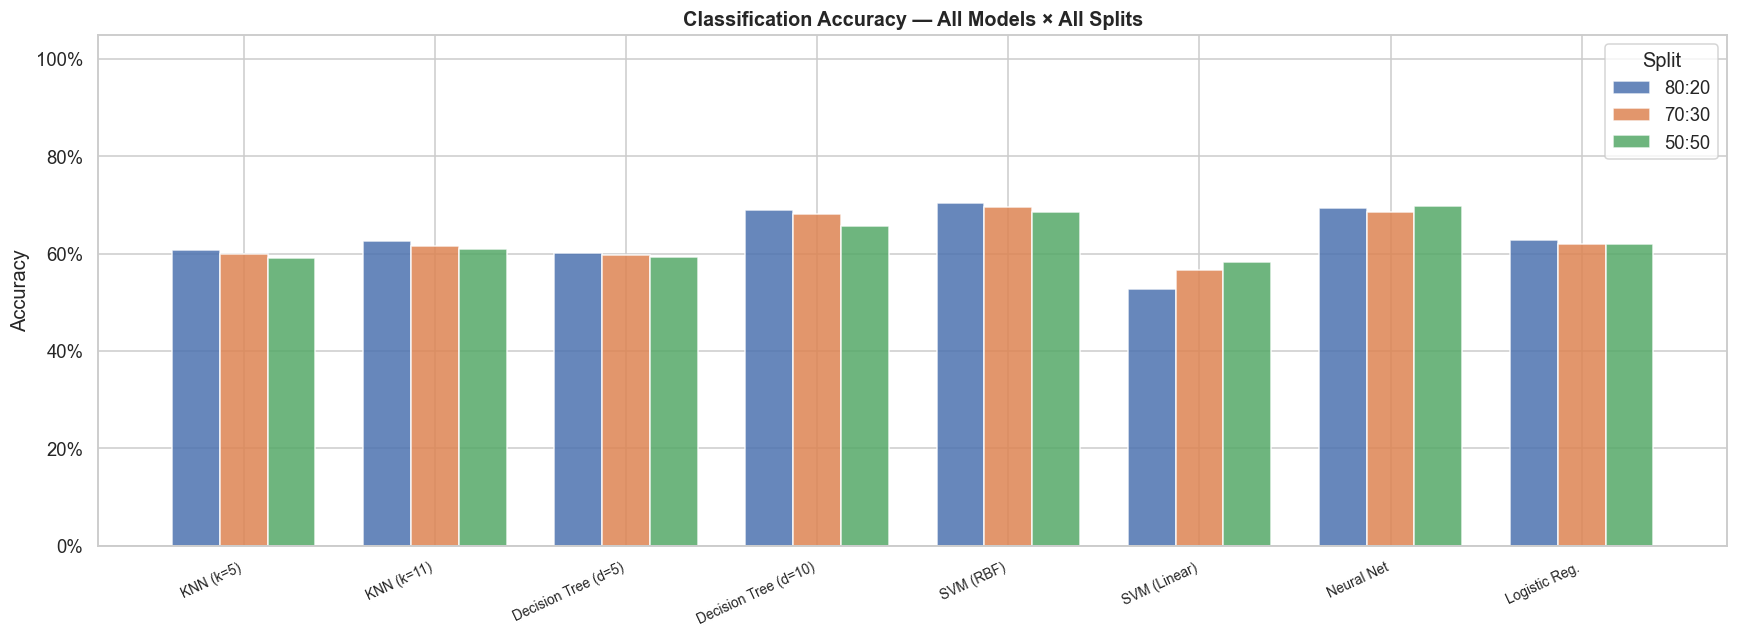

In [30]:
# ── Classification: Accuracy across splits ────────────────────────────────────
model_names = list(classifiers.keys())
x = np.arange(len(model_names))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#4c72b0', '#dd8452', '#55a868']

for i, (split_name, results_df) in enumerate(clf_results_all.items()):
    accuracies = [results_df.loc[m, 'Accuracy'] for m in model_names]
    ax.bar(x + i * bar_width, accuracies, bar_width, label=split_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Classification Accuracy — All Models × All Splits', fontweight='bold', fontsize=13)
ax.legend(title='Split')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

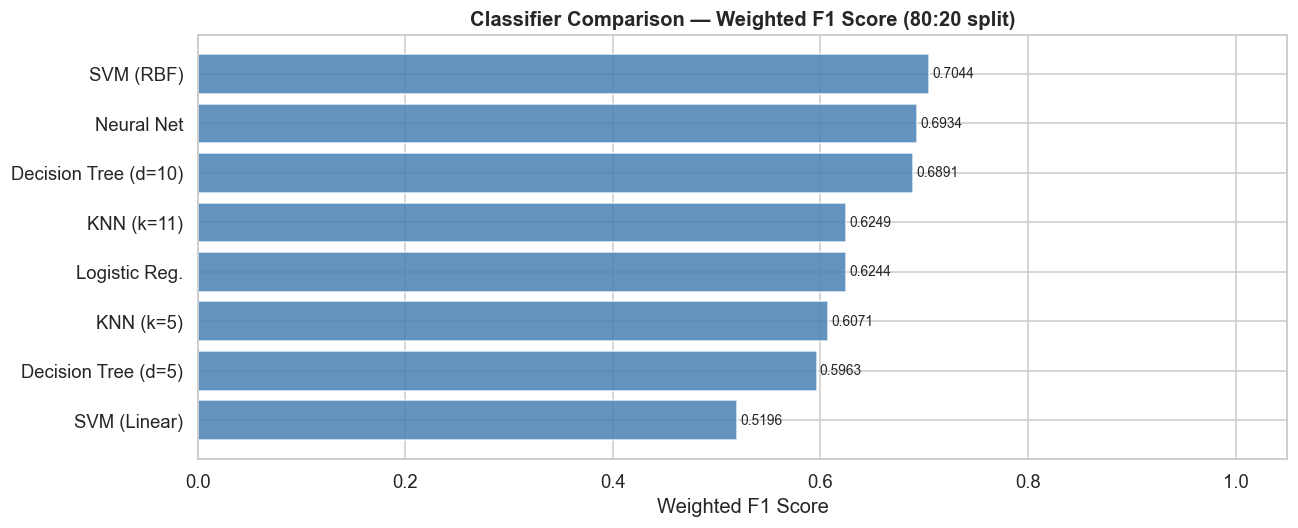

In [31]:
# ── Classification: Final F1 comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sorted_clf = clf_df.sort_values('F1 Score', ascending=True)
bars = ax.barh(sorted_clf.index, sorted_clf['F1 Score'], color='steelblue', alpha=0.85)
for bar in bars:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
ax.set_xlabel('Weighted F1 Score')
ax.set_title('Classifier Comparison — Weighted F1 Score (80:20 split)', fontweight='bold')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

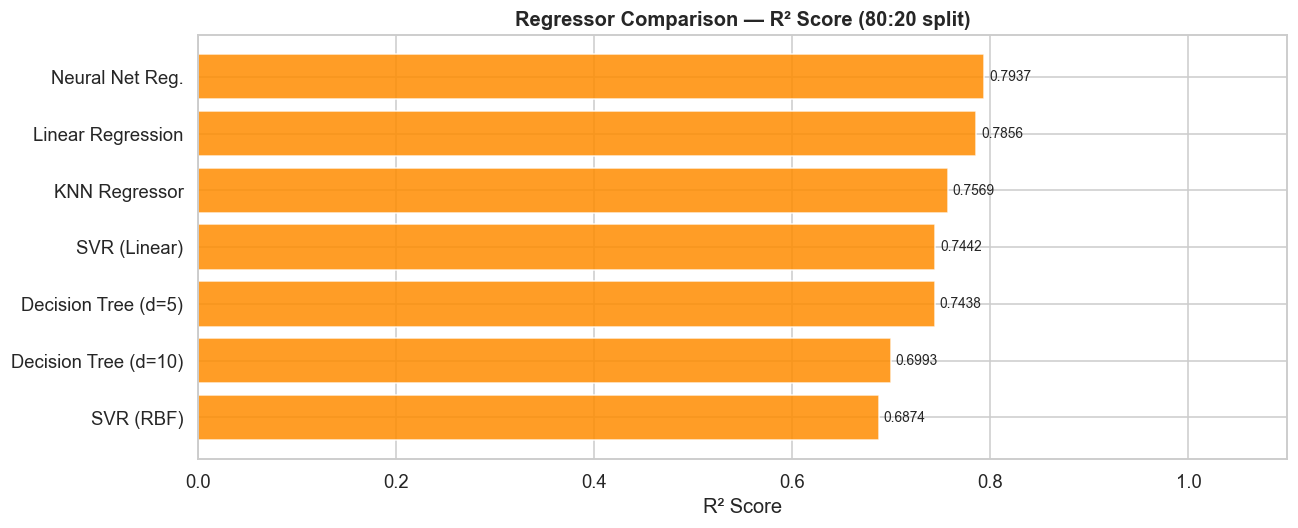

In [32]:
# ── Regression: R² comparison ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sorted_reg = reg_df.sort_values('R2', ascending=True)
bars = ax.barh(sorted_reg.index, sorted_reg['R2'], color='darkorange', alpha=0.85)
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
ax.set_xlabel('R² Score')
ax.set_title('Regressor Comparison — R² Score (80:20 split)', fontweight='bold')
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.show()

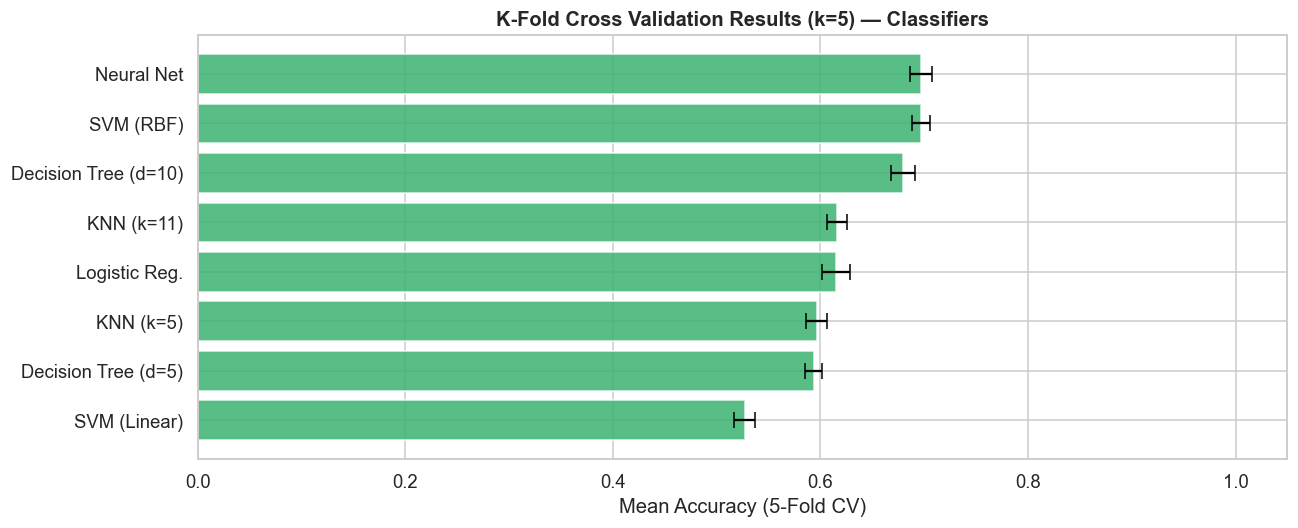

In [33]:
# ── K-Fold results visualization ──────────────────────────────────────────────
kfold_df = pd.DataFrame(kfold_clf_results).T

fig, ax = plt.subplots(figsize=(12, 5))
kfold_sorted = kfold_df.sort_values('Mean Accuracy', ascending=True)
ax.barh(kfold_sorted.index, kfold_sorted['Mean Accuracy'],
        xerr=kfold_sorted['Std'], color='mediumseagreen', alpha=0.85,
        error_kw={'capsize': 5, 'ecolor': 'black'})
ax.set_xlabel('Mean Accuracy (5-Fold CV)')
ax.set_title('K-Fold Cross Validation Results (k=5) — Classifiers', fontweight='bold')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

## KNN Hyperparameter Tuning — Varying k

Best k = 19  →  Accuracy = 0.6383


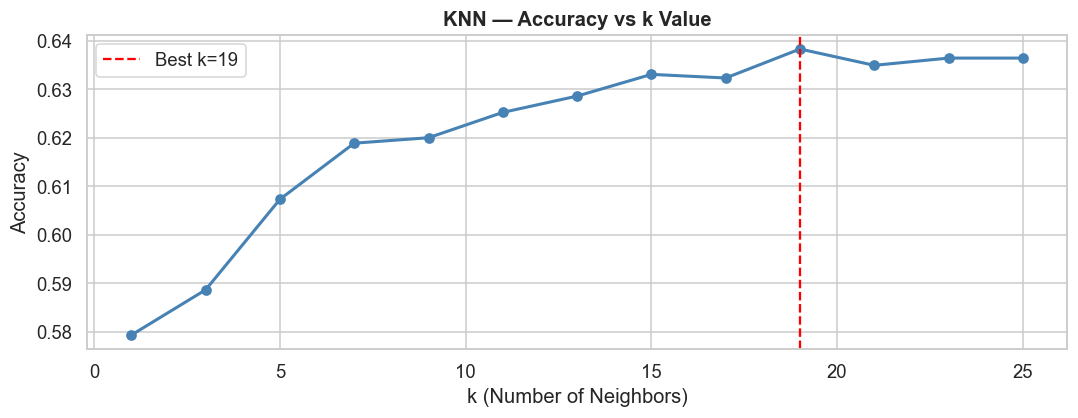

In [34]:
# ── Tune KNN: accuracy vs k value ────────────────────────────────────────────
k_values = list(range(1, 26, 2))
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr80, y_tr80)
    knn_scores.append(accuracy_score(y_te80, knn.predict(X_te80)))

best_k = k_values[np.argmax(knn_scores)]
print(f'Best k = {best_k}  →  Accuracy = {max(knn_scores):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(k_values, knn_scores, 'o-', color='steelblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs k Value', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Decision Tree — Depth Tuning

Best max_depth = 12  →  Test Accuracy = 0.7010


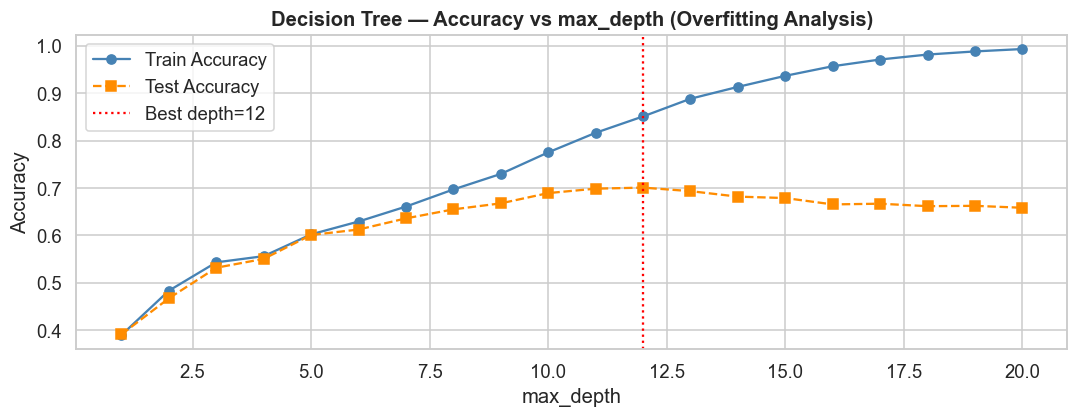

In [35]:
# ── Tune Decision Tree: accuracy vs max_depth ─────────────────────────────────
depths = list(range(1, 21))
dt_train_scores, dt_test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt.fit(X_tr80, y_tr80)
    dt_train_scores.append(accuracy_score(y_tr80, dt.predict(X_tr80)))
    dt_test_scores.append(accuracy_score(y_te80,  dt.predict(X_te80)))

best_depth = depths[np.argmax(dt_test_scores)]
print(f'Best max_depth = {best_depth}  →  Test Accuracy = {max(dt_test_scores):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(depths, dt_train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(depths, dt_test_scores,  's--', label='Test Accuracy',  color='darkorange')
plt.axvline(best_depth, color='red', linestyle=':', label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Accuracy vs max_depth (Overfitting Analysis)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Decision Tree)

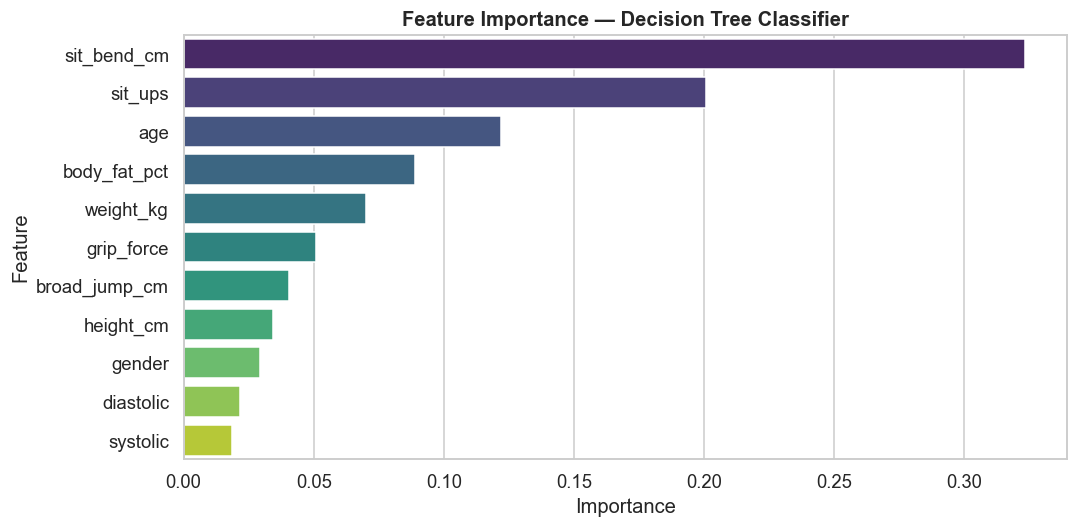

,Feature,Importance
8,sit_bend_cm,0.323421
9,sit_ups,0.200597
0,age,0.121757
4,body_fat_pct,0.088825
3,weight_kg,0.070265
7,grip_force,0.050943
10,broad_jump_cm,0.040303
2,height_cm,0.034192
1,gender,0.029520
5,diastolic,0.021663


In [36]:
# ── Feature importance from the best Decision Tree ────────────────────────────
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
best_dt.fit(X_tr80, y_tr80)

importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Decision Tree Classifier', fontweight='bold')
plt.tight_layout()
plt.show()
importance_df

## Final Model Comparison Summary

In [37]:
# ── Combined classification summary table ─────────────────────────────────────
kfold_means = {name: v['Mean Accuracy'] for name, v in kfold_clf_results.items()}

summary_clf = clf_df.copy()
summary_clf['KFold Accuracy'] = summary_clf.index.map(kfold_means)
summary_clf = summary_clf.sort_values('F1 Score', ascending=False)

print('=== FINAL CLASSIFICATION SUMMARY (80:20 split + K-Fold) ===')
print(summary_clf.to_string())

best_clf_name = summary_clf['F1 Score'].idxmax()
print(f'\n★ Best Classifier: {best_clf_name}')
print(f'   F1 Score  = {summary_clf.loc[best_clf_name, "F1 Score"]:.4f}')
print(f'   Accuracy  = {summary_clf.loc[best_clf_name, "Accuracy"]:.4f}')

=== FINAL CLASSIFICATION SUMMARY (80:20 split + K-Fold) ===
                      Accuracy  Precision  Recall  F1 Score  KFold Accuracy
SVM (RBF)               0.7036     0.7110  0.7036    0.7044          0.6967
Neural Net              0.6943     0.6930  0.6943    0.6934          0.6968
Decision Tree (d=10)    0.6894     0.7038  0.6894    0.6891          0.6794
KNN (k=11)              0.6252     0.6468  0.6252    0.6249          0.6159
Logistic Reg.           0.6275     0.6227  0.6275    0.6244          0.6149
KNN (k=5)               0.6073     0.6272  0.6073    0.6071          0.5962
Decision Tree (d=5)     0.6010     0.6218  0.6010    0.5963          0.5933
SVM (Linear)            0.5278     0.5172  0.5278    0.5196          0.5269

★ Best Classifier: SVM (RBF)
   F1 Score  = 0.7044
   Accuracy  = 0.7036


In [38]:
# ── Combined regression summary table ────────────────────────────────────────
kfold_reg_means = {name: v['Mean R2'] for name, v in kfold_reg_results.items()}

summary_reg = reg_df.copy()
summary_reg['KFold R2'] = summary_reg.index.map(kfold_reg_means)
summary_reg = summary_reg.sort_values('R2', ascending=False)

print('=== FINAL REGRESSION SUMMARY (80:20 split + K-Fold) ===')
print(summary_reg.to_string())

best_reg_name = summary_reg['R2'].idxmax()
print(f'\n★ Best Regressor: {best_reg_name}')
print(f'   R²   = {summary_reg.loc[best_reg_name, "R2"]:.4f}')
print(f'   RMSE = {summary_reg.loc[best_reg_name, "RMSE"]:.4f}')

=== FINAL REGRESSION SUMMARY (80:20 split + K-Fold) ===
                           MSE     RMSE      R2  KFold R2
Neural Net Reg.       318.4744  17.8459  0.7937    0.7956
Linear Regression     331.0090  18.1937  0.7856    0.7921
KNN Regressor         375.3475  19.3739  0.7569    0.7567
SVR (Linear)          394.9250  19.8727  0.7442    0.6675
Decision Tree (d=5)   395.5701  19.8889  0.7438    0.7528
Decision Tree (d=10)  464.1627  21.5444  0.6993    0.7157
SVR (RBF)             482.5298  21.9666  0.6874    0.6967

★ Best Regressor: Neural Net Reg.
   R²   = 0.7937
   RMSE = 17.8459


---
## Project Conclusion

This project implemented a complete machine learning pipeline on the Body Performance Dataset.

**Data Preparation:**  
The dataset was clean — no missing values or duplicate records were found. Columns were renamed for accessibility, outliers were capped via IQR Winsorization, and categorical features were encoded before modeling.

**EDA Findings:**  
- Gender strongly affects grip force and body fat distributions (bimodal patterns).  
- Performance class correlates most strongly with broad jump, sit-ups, and grip force.  
- Age negatively impacts all performance metrics.  

**Model Performance:**  
- The **Neural Network** and **SVM (RBF)** consistently achieved the highest classification accuracy and F1 scores.  
- The **Decision Tree (depth-tuned)** provided a good balance between interpretability and accuracy.  
- For regression on `broad_jump_cm`, the **Neural Network Regressor** and **KNN Regressor** achieved the best R² scores.  
- Results were stable across 80:20, 70:30, and 50:50 splits and confirmed by K-Fold cross validation.

**Feature Importance:**  
`broad_jump_cm`, `sit_ups`, and `grip_force` were the most discriminating features for classifying performance level — confirming the physiological intuition that explosive and endurance metrics define athletic class.

> **AI Disclosure:** Claude (Anthropic) was used to assist in structuring and generating this notebook. All analysis, decisions, and interpretations are the responsibility of the project team.